In [1]:
# Data combination

import pandas as pd



   # Load first file
df1 = pd.read_csv("C:/Users/Dianalaura Cueto/Electricity Prices Forecast/data/Clean/Baja California/PreciosNodos_BCA_ABRIL01-15_clean.csv")

   # Load second file
df2 = pd.read_csv("C:/Users/Dianalaura Cueto/Electricity Prices Forecast/data/Clean/Baja California/PreciosNodos_BCA_ABRIL16-30_clean.csv")

   # Combine
df = pd.concat([df1, df2], ignore_index=True)

df.to_csv("C:/Users/Dianalaura Cueto/Electricity Prices Forecast/data/Clean/Baja California/PreciosNodos_BCA_ABRIL26_clean.csv", index=False, encoding='utf-8-sig')



   

In [2]:
df.shape

(2880, 9)

In [3]:
df["Fecha"].min(),df["Fecha"].max() # checking that is within the date range

('2026-04-01', '2026-04-30')

In [4]:
df.isnull().sum() # checking for null values

Fecha                          0
Hora                           0
Zona de Carga                  0
Precio Zonal ($/MWh)           0
Componente energia ($/MWh)     0
Componente perdidas ($/MWh)    0
Extra1                         0
Extra2                         0
Extra3                         0
dtype: int64

In [5]:
df.duplicated().sum() # checking for  duplicated values 

np.int64(0)

In [6]:
# Change the Time column format to hh/]: mm format and combine the date column into a datetime column

# Change the format of Fecha column from / to -
df["Fecha_Clean"] = pd.to_datetime(df["Fecha"], errors="coerce").dt.strftime("%Y-%m-%d")

# 3. Change format of Hora column to  HH:MM starting in 00:00
df["Hora_Formatted"] = df["Hora"].astype(int).apply(lambda x: f"{x-1:02d}:00")

# 4. Combined data into Datetime column
df["Datetime"] = df["Fecha_Clean"] + " " + df["Hora_Formatted"]

# 5. Eliminate Fecha, Hora and formatted columns
df.drop(columns=["Fecha", "Hora", "Fecha_Clean", "Hora_Formatted", "Componente energia ($/MWh)", "Componente perdidas ($/MWh)", "Extra1", "Extra2", "Extra3"], errors="ignore", inplace=True)

# 6. Move Datetime to the first column space
cols = ["Datetime"] + [col for col in df.columns if col != "Datetime"]
df = df[cols]

df.rename(columns={"Precio Zonal ($/MWh)": "Precio"}, inplace=True)
df.rename(columns={"Zona de Carga": "Zona"}, inplace=True)

df.head()
df["Datetime"] = pd.to_datetime(df["Datetime"])

In [7]:
df.to_csv("C:/Users/Dianalaura Cueto/Electricity Prices Forecast/data/Clean/Baja California/PreciosNodos_BCA_ABRIL26_Forcasting_clean.csv", index=False, encoding='utf-8-sig')

In [8]:
#Statistics and trends  of each zone 

#MEXICALI
mexicali = df[df["Zona"] == "MEXICALI"]
mexicali["Precio"].describe()

count    720.000000
mean     296.648486
std      217.988955
min        0.000000
25%      100.365000
50%      219.305000
75%      386.132500
max      845.040000
Name: Precio, dtype: float64

In [9]:
mexicali["Precio"].std() #standard deviation

np.float64(217.98895540552002)

In [10]:
mexicali["Precio"].std() / mexicali["Precio"].mean() # coefficient of variation

np.float64(0.7348392646907734)

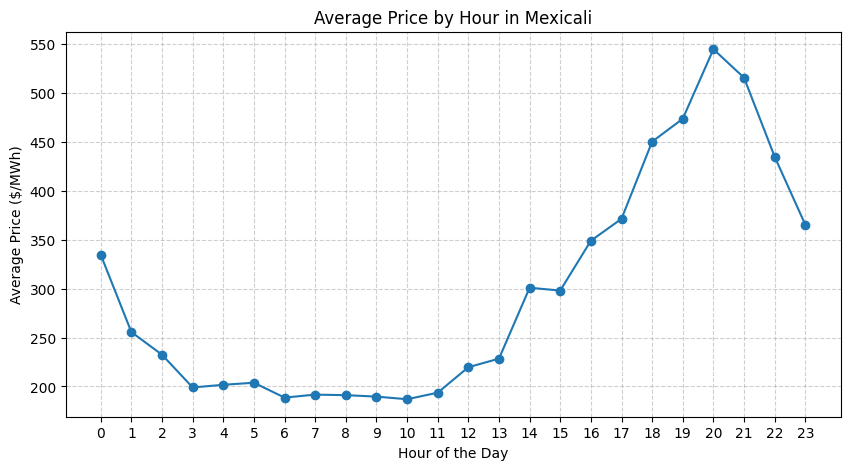

In [11]:
import matplotlib.pyplot as plt
mexicali.groupby(mexicali["Datetime"].dt.hour)["Precio"].mean().plot(
    kind="line", marker="o", figsize=(10, 5)
)
plt.title("Average Price by Hour in Mexicali")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Price ($/MWh)")
plt.xticks(range(0, 24))  # Show every hour on the x-axis
plt.grid(True, linestyle="--", alpha=0.6)

# Display the plot
plt.show()

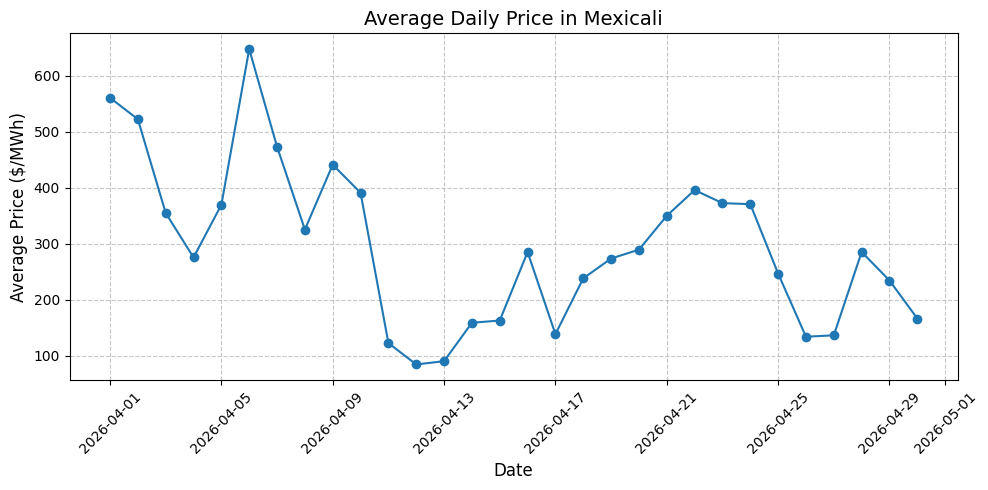

In [12]:
mexicali.groupby(mexicali["Datetime"].dt.date)["Precio"].mean().plot(
    kind="line", marker="o", figsize=(10, 5)
)


plt.title("Average Daily Price in Mexicali", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Price ($/MWh)", fontsize=12)


plt.grid(True, linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

24      2
25      2
26      2
27      2
28      2
       ..
2827    3
2828    3
2829    3
2830    3
2831    3
Name: day_of_week, Length: 720, dtype: int32


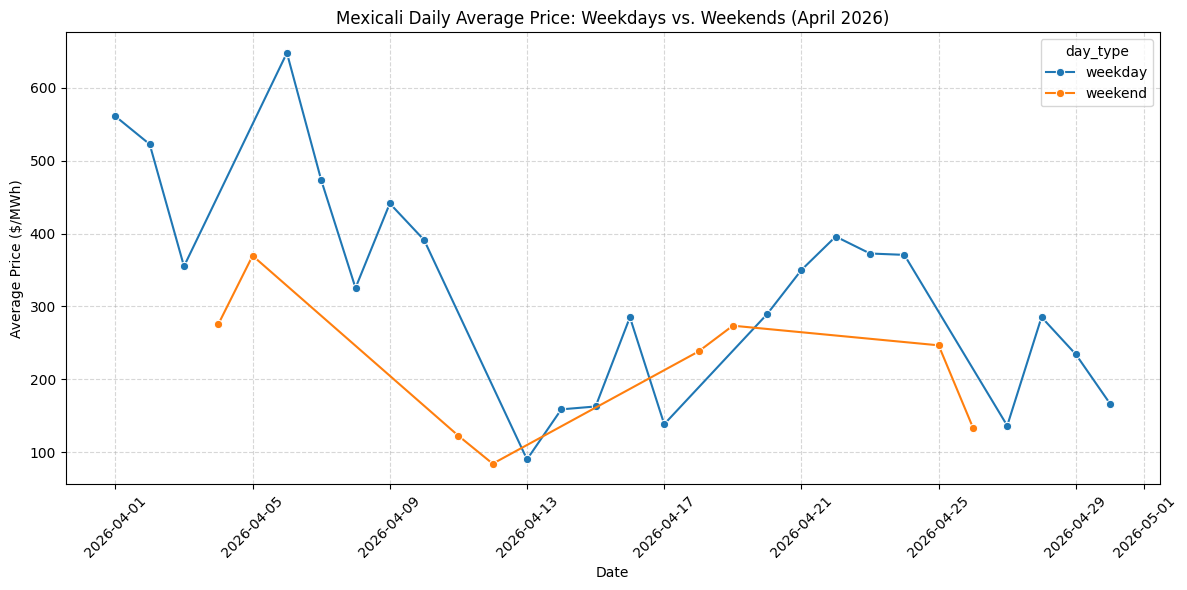

In [13]:
import numpy as np
import seaborn as sns

mexicali["day_of_week"] = mexicali["Datetime"].dt.dayofweek
print(mexicali["day_of_week"])
#create date of week monday tuesday

# Classify as Weekday (0-4) or Weekend (5-6)
mexicali["day_type"] = np.where(mexicali["day_of_week"] < 5, "weekday", "weekend")

#calculate average 
daily_avg = (
    mexicali.groupby([mexicali["Datetime"].dt.date, "day_type"])["Precio"]
    .mean()
    .reset_index()
)
daily_avg.columns = ["date", "day_type", "average_precio"]


#Plot

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=daily_avg,
    x="date",
    y="average_precio",
    hue="day_type",
    marker="o",
    palette={"weekday": "#1f77b4", "weekend": "#ff7f0e"},
)

plt.title("Mexicali Daily Average Price: Weekdays vs. Weekends (April 2026)")
plt.xlabel("Date")
plt.ylabel("Average Price ($/MWh)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [35]:
#OBSERVATIONS FOR MEXICALI APRIL 2026

#Most expensive time of the day
mexicali_hourly_max=mexicali.groupby(mexicali["Datetime"].dt.hour)["Precio"].mean().idxmax()
print(f"The most expensive time of the day for Mexicali during April 2026 is: {mexicali_hourly_max}")


#Most expensive time of the month
mexicali_daily_max= mexicali.groupby(mexicali["Datetime"].dt.date)["Precio"].mean().idxmax()
print(f"The averaged most expensive day for Mexicali during April 2026 is: {mexicali_daily_max}")

#Average prices: difference between weekdays and weekends



The most expensive time of the day for Mexicali during April 2026 is: 20
The averaged most expensive day for Mexicali during April 2026 is: 2026-04-06


In [15]:
#ENSENADA
ensenada = df[df["Zona"] == "ENSENADA"]
ensenada["Precio"].describe()

count     720.000000
mean      360.348681
std       581.588683
min         0.000000
25%       107.655000
50%       227.780000
75%       406.217500
max      5793.170000
Name: Precio, dtype: float64

In [16]:
ensenada["Precio"].std() #standard deviation

np.float64(581.5886825855611)

In [17]:
ensenada["Precio"].std() / ensenada["Precio"].mean() # coefficient of variation

np.float64(1.6139609050015562)

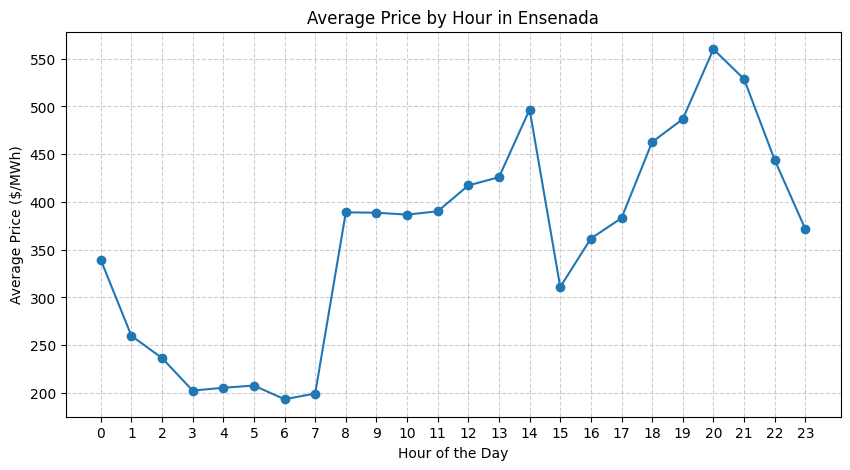

In [18]:
ensenada.groupby(ensenada["Datetime"].dt.hour)["Precio"].mean().plot(
    kind="line", marker="o", figsize=(10, 5)
)
plt.title("Average Price by Hour in Ensenada")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Price ($/MWh)")
plt.xticks(range(0, 24))  # Show every hour on the x-axis
plt.grid(True, linestyle="--", alpha=0.6)

# Display the plot
plt.show()

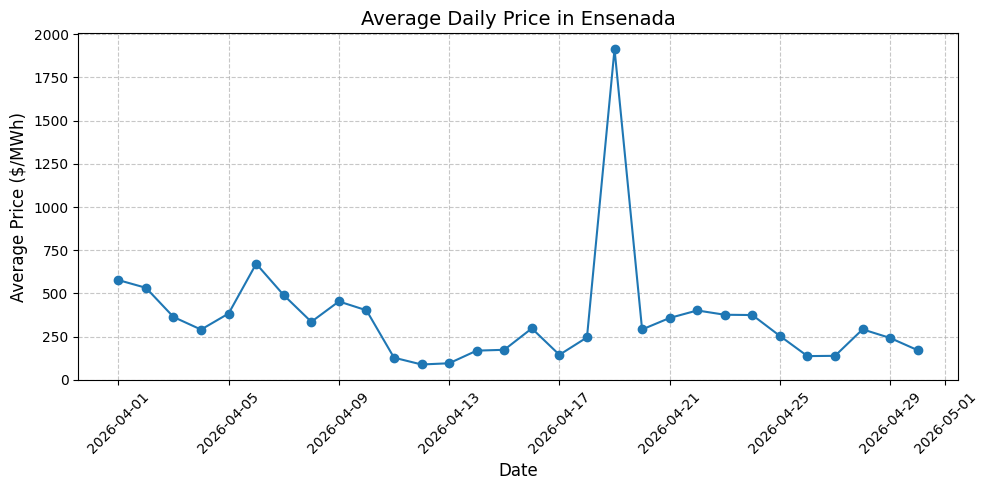

In [19]:
ensenada.groupby(ensenada["Datetime"].dt.date)["Precio"].mean().plot(
    kind="line", marker="o", figsize=(10, 5)
)

plt.title("Average Daily Price in Ensenada", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Price ($/MWh)", fontsize=12)


plt.grid(True, linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

0       2
1       2
2       2
3       2
4       2
       ..
2803    3
2804    3
2805    3
2806    3
2807    3
Name: day_of_week, Length: 720, dtype: int32


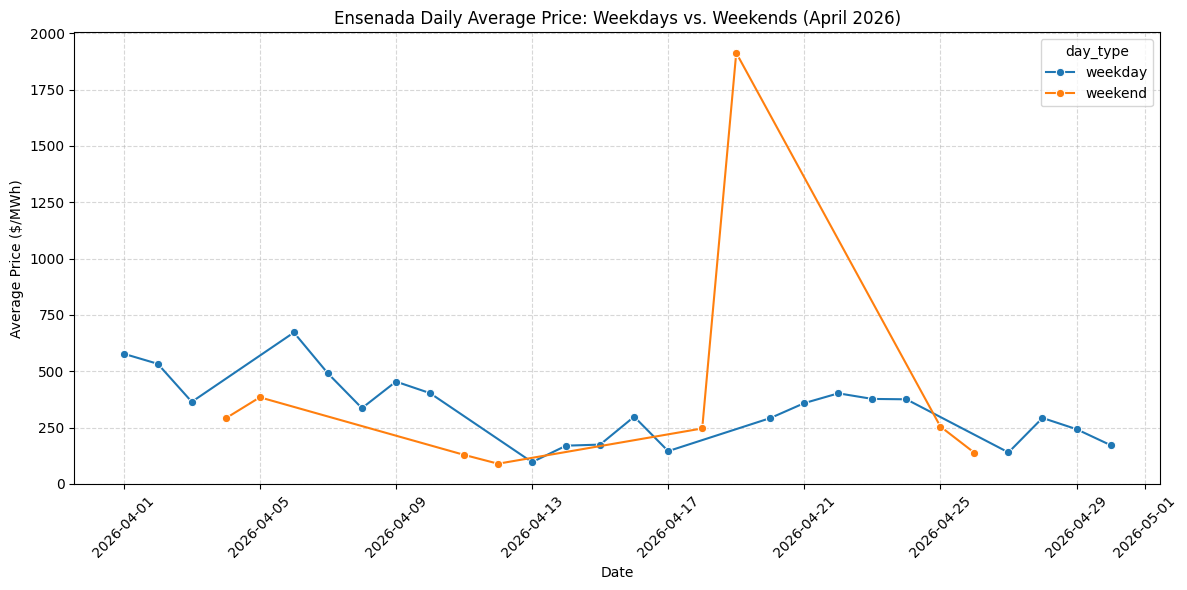

In [20]:
ensenada["day_of_week"] = ensenada["Datetime"].dt.dayofweek
print(ensenada["day_of_week"])
#create date of week monday tuesday

# Classify as Weekday (0-4) or Weekend (5-6)
ensenada["day_type"] = np.where(ensenada["day_of_week"] < 5, "weekday", "weekend")

#calculate average 
daily_avg = (
    ensenada.groupby([ensenada["Datetime"].dt.date, "day_type"])["Precio"]
    .mean()
    .reset_index()
)
daily_avg.columns = ["date", "day_type", "average_precio"]


#Plot

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=daily_avg,
    x="date",
    y="average_precio",
    hue="day_type",
    marker="o",
    palette={"weekday": "#1f77b4", "weekend": "#ff7f0e"},
)

plt.title("Ensenada Daily Average Price: Weekdays vs. Weekends (April 2026)")
plt.xlabel("Date")
plt.ylabel("Average Price ($/MWh)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [40]:
#Most expensive time of the day
ensenada_hourly_max=ensenada.groupby(ensenada["Datetime"].dt.hour)["Precio"].mean().idxmax()
print(f"The most expensive time of the day for Ensenada during April 2026 is: {ensenada_hourly_max}")


#Most expensive time of the month
ensenada_daily_max= ensenada.groupby(ensenada["Datetime"].dt.date)["Precio"].mean().idxmax()
print(f"The averaged most expensive day for Ensenada during April 2026 is: {ensenada_daily_max}")

The most expensive time of the day for Ensenada during April 2026 is: 20
The averaged most expensive day for Ensenada during April 2026 is: 2026-04-19


In [21]:
#TIJUANA
tijuana = df[df["Zona"] == "TIJUANA"]
tijuana["Precio"].describe()

count    720.000000
mean     300.829889
std      218.107174
min        0.000000
25%      104.895000
50%      222.600000
75%      391.772500
max      845.950000
Name: Precio, dtype: float64

In [22]:
tijuana["Precio"].std() #standard deviation

np.float64(218.10717445386592)

In [23]:
tijuana["Precio"].std() / tijuana["Precio"].mean() # coefficient of variation

np.float64(0.7250182994098153)

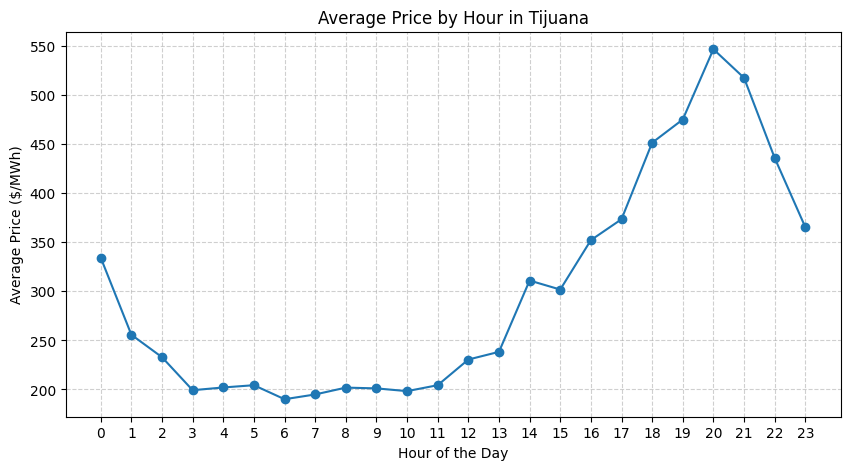

In [24]:
tijuana.groupby(tijuana["Datetime"].dt.hour)["Precio"].mean().plot(
    kind="line", marker="o", figsize=(10, 5)
)
plt.title("Average Price by Hour in Tijuana")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Price ($/MWh)")
plt.xticks(range(0, 24))  # Show every hour on the x-axis
plt.grid(True, linestyle="--", alpha=0.6)

# Display the plot
plt.show()

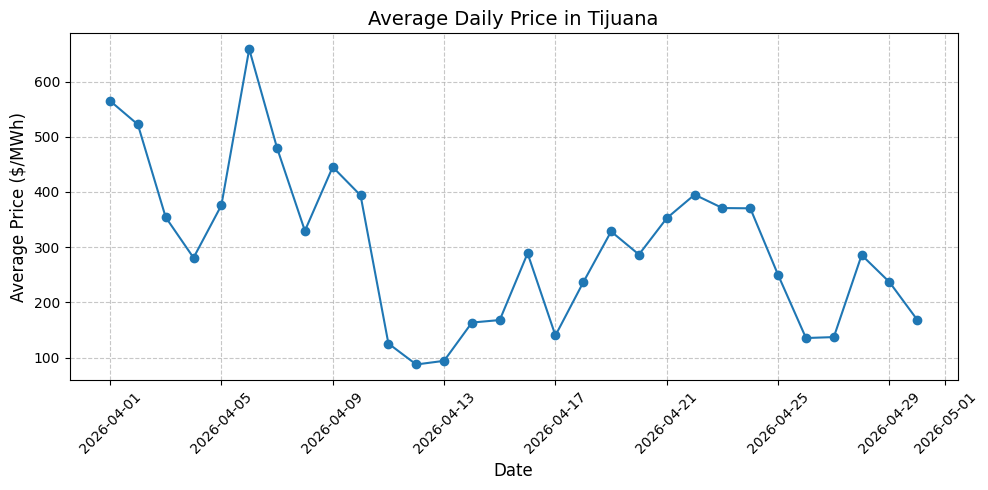

In [25]:
tijuana.groupby(tijuana["Datetime"].dt.date)["Precio"].mean().plot(
    kind="line", marker="o", figsize=(10, 5)
)

plt.title("Average Daily Price in Tijuana", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Price ($/MWh)", fontsize=12)


plt.grid(True, linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

72      2
73      2
74      2
75      2
76      2
       ..
2875    3
2876    3
2877    3
2878    3
2879    3
Name: day_of_week, Length: 720, dtype: int32


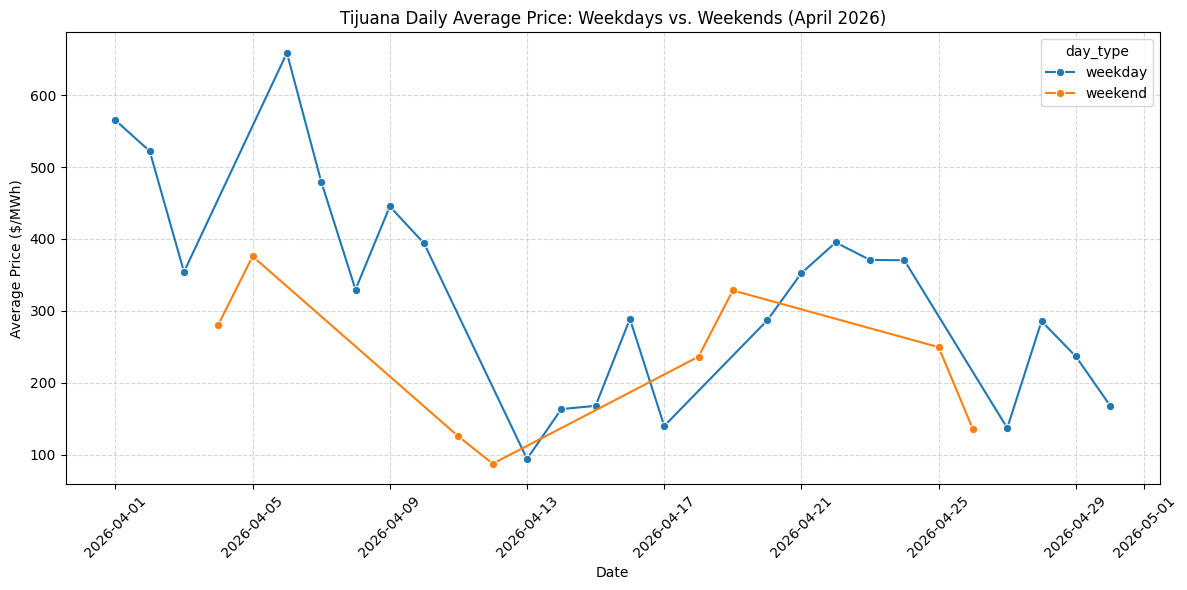

In [26]:
tijuana["day_of_week"] = tijuana["Datetime"].dt.dayofweek
print(tijuana["day_of_week"])
#create date of week monday tuesday

# Classify as Weekday (0-4) or Weekend (5-6)
tijuana["day_type"] = np.where(tijuana["day_of_week"] < 5, "weekday", "weekend")

#calculate average 
daily_avg = (
    tijuana.groupby([tijuana["Datetime"].dt.date, "day_type"])["Precio"]
    .mean()
    .reset_index()
)
daily_avg.columns = ["date", "day_type", "average_precio"]


#Plot

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=daily_avg,
    x="date",
    y="average_precio",
    hue="day_type",
    marker="o",
    palette={"weekday": "#1f77b4", "weekend": "#ff7f0e"},
)

plt.title("Tijuana Daily Average Price: Weekdays vs. Weekends (April 2026)")
plt.xlabel("Date")
plt.ylabel("Average Price ($/MWh)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [38]:
#Most expensive time of the day
tijuana_hourly_max=tijuana.groupby(tijuana["Datetime"].dt.hour)["Precio"].mean().idxmax()
print(f"The most expensive time of the day for Tijuana during April 2026 is: {tijuana_hourly_max}")


#Most expensive time of the month
tijuana_daily_max= tijuana.groupby(tijuana["Datetime"].dt.date)["Precio"].mean().idxmax()
print(f"The averaged most expensive day for Tijuana during April 2026 is: {tijuana_daily_max}")

The most expensive time of the day for Tijuana during April 2026 is: 20
The averaged most expensive day for Tijuana during April 2026 is: 2026-04-06


In [27]:
#SANLUIS
sanluis = df[df["Zona"] == "SANLUIS"]
sanluis["Precio"].describe()

count    720.000000
mean     298.861083
std      219.880983
min        0.000000
25%      100.892500
50%      220.325000
75%      388.430000
max      854.420000
Name: Precio, dtype: float64

In [28]:
sanluis["Precio"].std() #standard deviation

np.float64(219.88098325872738)

In [29]:
sanluis["Precio"].std() / sanluis["Precio"].mean() # coefficient of variation

np.float64(0.7357297270233212)

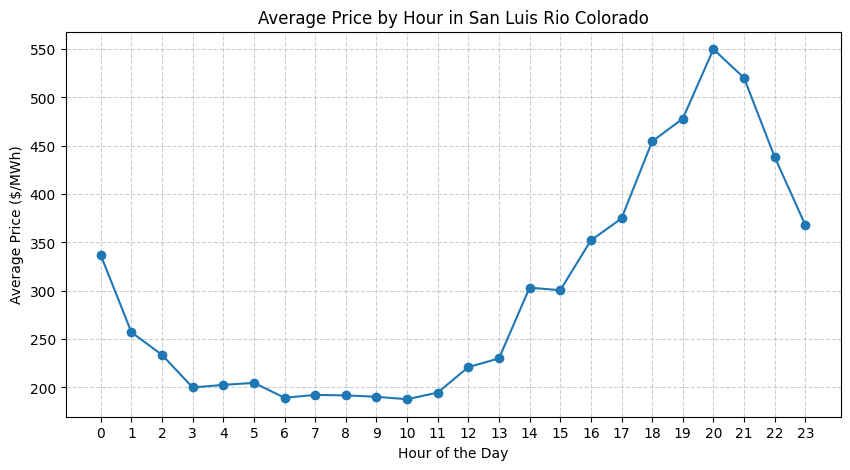

In [30]:
sanluis.groupby(sanluis["Datetime"].dt.hour)["Precio"].mean().plot(
    kind="line", marker="o", figsize=(10, 5)
)
plt.title("Average Price by Hour in San Luis Rio Colorado")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Price ($/MWh)")
plt.xticks(range(0, 24))  # Show every hour on the x-axis
plt.grid(True, linestyle="--", alpha=0.6)

# Display the plot
plt.show()

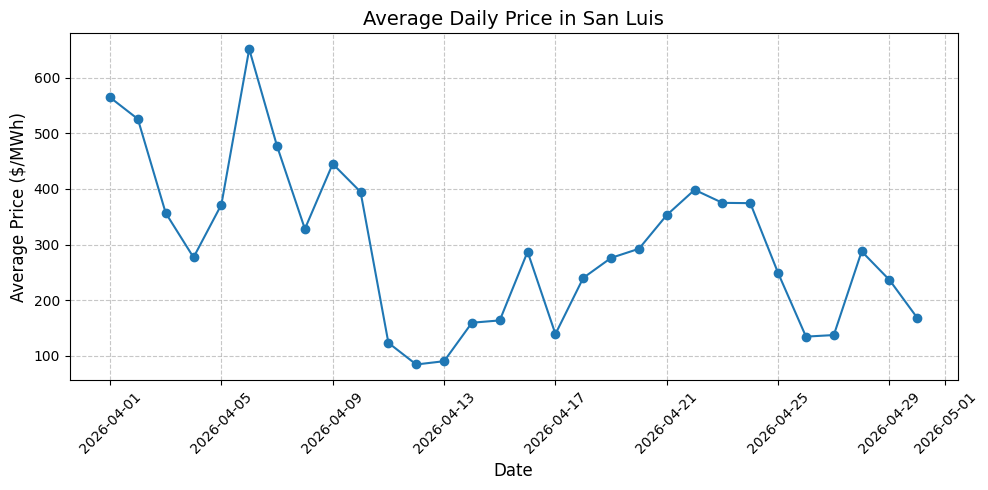

In [31]:
sanluis.groupby(sanluis["Datetime"].dt.date)["Precio"].mean().plot(
    kind="line", marker="o", figsize=(10, 5)
)

plt.title("Average Daily Price in San Luis", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Price ($/MWh)", fontsize=12)


plt.grid(True, linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

48      2
49      2
50      2
51      2
52      2
       ..
2851    3
2852    3
2853    3
2854    3
2855    3
Name: day_of_week, Length: 720, dtype: int32


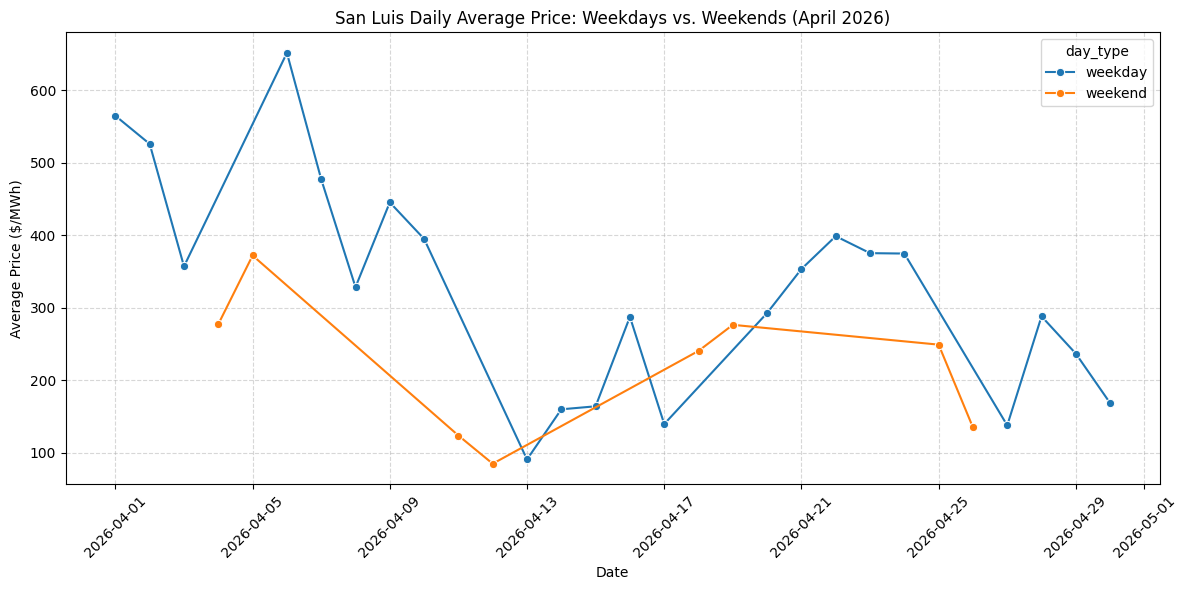

In [32]:
sanluis["day_of_week"] = sanluis["Datetime"].dt.dayofweek
print(sanluis["day_of_week"])
#create date of week monday tuesday
# Classify as Weekday (0-4) or Weekend (5-6)
sanluis["day_type"] = np.where(sanluis["day_of_week"] < 5, "weekday", "weekend")

#calculate average 
daily_avg = (
    sanluis.groupby([sanluis["Datetime"].dt.date, "day_type"])["Precio"]
    .mean()
    .reset_index()
)
daily_avg.columns = ["date", "day_type", "average_precio"]


#Plot

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=daily_avg,
    x="date",
    y="average_precio",
    hue="day_type",
    marker="o",
    palette={"weekday": "#1f77b4", "weekend": "#ff7f0e"},
)

plt.title("San Luis Daily Average Price: Weekdays vs. Weekends (April 2026)")
plt.xlabel("Date")
plt.ylabel("Average Price ($/MWh)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [39]:
#Most expensive time of the day
sanluis_hourly_max=sanluis.groupby(sanluis["Datetime"].dt.hour)["Precio"].mean().idxmax()
print(f"The most expensive time of the day for San Luis during April 2026 is: {sanluis_hourly_max}")


#Most expensive time of the month
sanluis_daily_max= sanluis.groupby(sanluis["Datetime"].dt.date)["Precio"].mean().idxmax()
print(f"The averaged most expensive day for San Luis during April 2026 is: {sanluis_daily_max}")

The most expensive time of the day for San Luis during April 2026 is: 20
The averaged most expensive day for San Luis during April 2026 is: 2026-04-06


In [ ]:

print(f"Ensenada dislayed high congestion prices in {sanluis_daily_max},a Sunday")